In [1]:
# @title Install and import libraries for Barrett et al., 2025, Figure 1
!pip install pingouin > /dev/null 2>&1
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pingouin as pg
import requests
import pandas as pd
import seaborn as sns
from IPython.display import Image
import numpy as np
import zipfile
from io import BytesIO
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os

# Plot settings
font_sizes = {
    'title': 8,
    'xlabel': 8,
    'ylabel': 7,
    'xticks': 6,
    'yticks': 6,
    'legend': 6,
    'inset_title': 6,
    'inset_ylabel': 6,
    'anova_text': 5
}
plt.rcParams['font.family'] = 'DejaVu Sans'
fig_width_in = 60 / 25.4
fig_height_in = 45 / 25.4

def load_Fig1F_from_github(username, repo, branch, folder, file_name):
    # Construct the URL for GitHub download
    file_url = f"https://github.com/{username}/{repo}/raw/{branch}/{folder}/{file_name}"

    # Download the zip file
    file_response = requests.get(file_url)

    if file_response.status_code == 200:
        try:
            with zipfile.ZipFile(BytesIO(file_response.content)) as zip_file:
                dfs = []

                for file_name in zip_file.namelist():
                    with zip_file.open(file_name) as file:
                        df = pd.read_csv(file)
                        df['Filename'] = file_name
                        dfs.append(df)

                # Combine all CSVs
                combined_df = pd.concat(dfs, ignore_index=True)
                combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'])
                print(f"Data loaded successfully!")
                return combined_df
        except zipfile.BadZipFile:
            print("Failed to open ZIP file. Ensure the file is a valid ZIP archive.")
            return None
    else:
        print(f"Failed to download the file: {file_response.status_code}")
        return None

# Arguments for the GitHub import function
username = "KravitzLab"
repo = "Barrett2024"
branch = "main"

print ("Libraries imported")

Libraries imported


In [2]:
# @title Figure 1A
Image(url='https://github.com/KravitzLab/Barrett2024/blob/main/Images/Barrett_1A.jpg?raw=true', width=300)

In [3]:
# @title Figure 1B
Image(url='https://github.com/KravitzLab/Barrett2024/blob/main/Images/Barrett_1B.jpg?raw=true', width=300)

In [4]:
# @title Figure 1C
Image(url='https://github.com/KravitzLab/Barrett2024/blob/main/Images/Barrett_1C.jpg?raw=true', width=600)

In [5]:
# @title Figure 1D
Image(url='https://github.com/KravitzLab/Barrett2024/blob/main/Images/Barrett_1D.jpg?raw=true', width=300)

Average Weights per Phase:
Fr1 with chow: 27.197
Free with chow: 27.281

T-test p-value:
0.398117


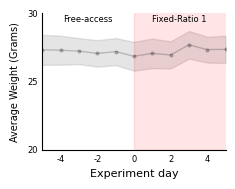

In [6]:
# @title Figure 1E

# import and clean data
Fig1Edata = pd.read_csv(r"https://raw.githubusercontent.com/KravitzLab/Barrett2024/refs/heads/main/Data/Fig1/Fig1E_Weights_and_Food.csv")
Fig1Edata['day'] = Fig1Edata['day'] - 1

# plot
combined_avg_data = Fig1Edata.groupby(['day', 'Phase'])['weight'].agg(['mean', 'sem']).reset_index()
fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in))
x, y, sem = combined_avg_data['day'], combined_avg_data['mean'], combined_avg_data['sem']
ax.plot(x, y, 'o-', color='black', alpha=0.2, linewidth=1.0, markersize=2)
ax.fill_between(x, y - sem, y + sem, color='grey', alpha=0.2)

# Background color blocks and labels
ax.add_patch(Rectangle((6, 20), 7.5, 15, color='red', alpha=0.1))
ax.text(3.5, 29.4, 'Free-access', ha='center', fontsize=6)
ax.text(8.5, 29.4, 'Fixed-Ratio 1', ha='center', fontsize=6)

# Axes limits, labels, and ticks
ax.set(xlim=(1, 11), ylim=(20, 30))
ax.set_xlabel('Experiment day', fontsize=font_sizes['xlabel'])
ax.set_ylabel('Average Weight (Grams)', fontsize=font_sizes['ylabel'], labelpad=5)
ax.set_xticks([2, 4, 6, 8, 10])
ax.set_xticklabels([-4, -2, 0, 2, 4], fontsize=font_sizes['xticks'])
ax.set_yticks([20, 25, 30])
ax.set_yticklabels([20, 25, 30], fontsize=font_sizes['yticks'])
ax.tick_params(axis='both', length=0)
sns.despine()

# Calculate mean weight per mouse per phase
mouse_phase_weights = Fig1Edata.groupby(['mouse', 'Phase'])['weight'].mean().unstack()

# Paired t-test
results = pg.ttest(mouse_phase_weights['Free with chow'], mouse_phase_weights['Fr1 with chow'], paired=True)

#Print results
# Display mean weights per phase
mean_weights = mouse_phase_weights.mean()
print("Average Weights per Phase:")
print(f"Fr1 with chow: {mean_weights['Fr1 with chow']:.3f}")
print(f"Free with chow: {mean_weights['Free with chow']:.3f}")
print("\nT-test p-value:")
print(f"{results['p-val'].iloc[0]:.6f}")

Data loaded successfully!


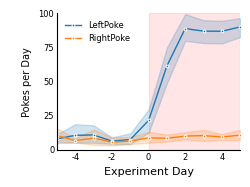

In [7]:
# @title Figure 1F

# Load the data from GitHub
folder = "Data/Fig1"
file_name = "Castle_ChowData_Cleaned.zip"
combined_df = load_Fig1F_from_github(username, repo, branch, folder, file_name)

# Extract experiment time
combined_df['Hour'] = combined_df['Timestamp'].dt.hour
combined_df['ExptHour'] = combined_df['Hour'] - 16
combined_df['ExptHour'] = combined_df['ExptHour'].apply(lambda x: x + 24 if x < 0 else x)
combined_df['ExptTime'] = (combined_df['ExptDay'] + combined_df['ExptHour'] / 24.0).round(2)

# Data processing for daily summary
daily_df = combined_df.groupby(['ExptDay', 'Filename']).mean(numeric_only=True).reset_index().round(2)
daily_df = daily_df.sort_values(by=["Filename", "ExptTime"])
daily_df["LeftCount_diff"] = daily_df.groupby("Filename")["LeftCount"].diff()
daily_df["RightCount_diff"] = daily_df.groupby("Filename")["RightCount"].diff()

# Create the plot for Set 2 (correct pokes plot)
fig, ax2 = plt.subplots(figsize=(fig_width_in, fig_height_in))

# Plot for Set 2
ax2.add_patch(Rectangle((0, 0), 5, 100, color='red', alpha=0.1))
sns.lineplot(data=daily_df, x="ExptDay", y="LeftCount_diff", lw=1, label="LeftPoke", marker="o", markersize=2, ax=ax2)
sns.lineplot(data=daily_df, x="ExptDay", y="RightCount_diff", lw=1, label="RightPoke", marker="o", markersize=2, ax=ax2)
ax2.set_ylim(0, 100)
ax2.set_xlim(-5, 5)
ax2.set_xlabel('Experiment Day', fontsize=font_sizes['xlabel'])
ax2.set_ylabel(' \nPokes per Day', fontsize=font_sizes['ylabel'], labelpad=5)
plt.legend(frameon=False, loc='upper left', fontsize=font_sizes['legend'])
ax2.set_xticks([-4, -2, 0, 2, 4])
ax2.set_xticklabels([-4, -2, 0, 2, 4], fontsize=font_sizes['xticks'])
ax2.set_yticks([0, 25, 50, 75, 100])
ax2.set_yticklabels([0, 25, 50, 75, 100], fontsize=font_sizes['yticks'])
ax2.tick_params(axis='both', which='both', length=0)
sns.despine()

# Adjust tick labels closer to axis lines
ax2.tick_params(axis='y', which='both', direction='out', length=0, width=0, pad=2)
ax2.tick_params(axis='x', which='both', direction='out', length=0, width=0, pad=2)

In [8]:
# @title Function for combining feeding events from TumbleFeeder touch data

# This function was run offline on all raw TumbleFeeder files to create the data for  the next cell "Fig1G_feeding_summary.csv"
# It is included here for completeness but was challenging to pull this data directly from a Github repo into a Colab environment so it was run offline.

def combineFeeds(df, hours=24, sliceFromEnd=True, combine_feeds_within=60, feed_filter=5):
    # Convert Timestamp to datetime and create a Seconds column
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%m/%d/%Y %H:%M:%S', errors='coerce')
    df['Seconds'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

    # Check the actual duration before slicing
    min_time = df['Timestamp'].min()
    max_time = df['Timestamp'].max()
    actual_duration = (max_time - min_time).total_seconds() / 3600

    if actual_duration < hours:
        print(f"Warning: Only {actual_duration:.2f} hours of data available for the requested {hours} hours. File: {df['Filename'].iloc[0] if 'Filename' in df.columns else 'Unknown File'}")

    # Filter based on hours and sliceFromEnd
    if sliceFromEnd:
        filtered_df = df[df['Timestamp'] >= max_time - pd.Timedelta(hours=hours)]
    else:
        filtered_df = df[df['Timestamp'] <= min_time + pd.Timedelta(hours=hours)]

    if filtered_df.empty:
        print(f"Warning: No data available for the specified duration ({hours} hours). File: {df['Filename'].iloc[0] if 'Filename' in df.columns else 'Unknown File'}")
        return pd.DataFrame(columns=['feedStart', 'feedEnd', 'feedDuration', 'filename', 'Device', 'Sex'])

    df = filtered_df

    # Initialize variables for processing feeding events
    summary_data = []
    feed_start = None
    prev_feed_seconds = None

    # Iterate through the rows to detect feeding events
    for _, row in df.iterrows():
        if row['LeftFeedDur'] > 0:  # Feeding detected
            if feed_start is None:  # Start a new feeding event
                feed_start = row['Seconds']
            elif prev_feed_seconds is not None and row['Seconds'] - prev_feed_seconds > combine_feeds_within:
                # End the current feeding event and start a new one
                feed_end = prev_feed_seconds
                feed_duration = feed_end - feed_start
                if feed_duration >= feed_filter:
                    summary_data.append({
                        'feedStart': feed_start,
                        'feedEnd': feed_end,
                        'feedDuration': feed_duration
                    })
                feed_start = row['Seconds']  # Start the new feeding event
        elif feed_start is not None and (prev_feed_seconds is not None and row['Seconds'] - prev_feed_seconds > combine_feeds_within):
            # End a feeding event when there is a gap beyond combine_feeds_within
            feed_end = prev_feed_seconds
            feed_duration = feed_end - feed_start
            if feed_duration >= feed_filter:
                summary_data.append({
                    'feedStart': feed_start,
                    'feedEnd': feed_end,
                    'feedDuration': feed_duration
                })
            feed_start = None  # Reset feed_start for the next event

        prev_feed_seconds = row['Seconds']

    # Handle the last feeding event
    if feed_start is not None and prev_feed_seconds - feed_start >= feed_filter:
        summary_data.append({
            'feedStart': feed_start,
            'feedEnd': prev_feed_seconds,
            'feedDuration': prev_feed_seconds - feed_start
        })

    # Convert to DataFrame
    summary_df = pd.DataFrame(summary_data)

    # Add filename and device information
    summary_df['filename'] = df['Filename'].iloc[0] if 'Filename' in df.columns else ''
    summary_df['Device'] = df['DeviceNumber'].iloc[0] if 'DeviceNumber' in df.columns else ''
    if not summary_df.empty and 'Device' in summary_df.columns:
        summary_df['Sex'] = 'M' if int(summary_df['Device'][0]) < 5 else 'F'
    else:
        summary_df['Sex'] = ''

    return summary_df


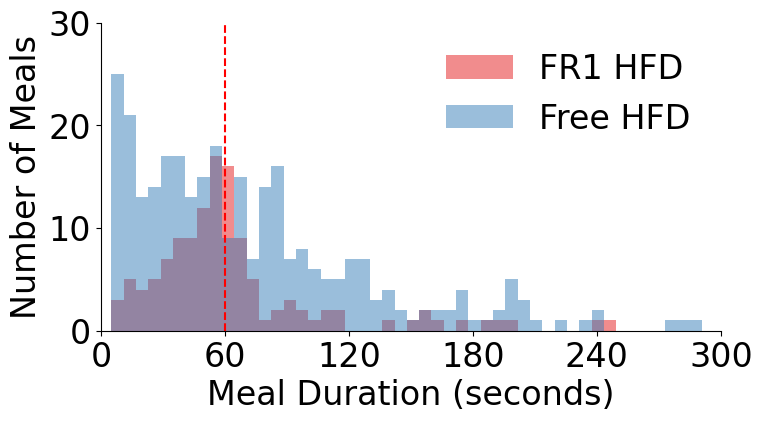

In [9]:
# @title Figure 1G

# import and clean data
Fig1Gdata = pd.read_csv(r"https://raw.githubusercontent.com/KravitzLab/Barrett2024/refs/heads/main/Data/Fig1/Fig1G_feeding_summary.csv")

# Specify tasks to include in the plot
selected_tasks = ['FR1 HFD',  'Free HFD']  # Can add "Free with chow" if wanted

# Use colors from the "Set1" palette
colors = plt.cm.Set1(range(len(selected_tasks)))

# Define consistent bins for all tasks
number_of_bins = 100
bin_edges = np.linspace(Fig1Gdata['feedDuration'].min(), Fig1Gdata['feedDuration'].max(), number_of_bins )

# Create the plot
plt.figure(figsize=(8, 4))

# Create a histogram for each selected task
for i, task in enumerate(selected_tasks):
    if task in Fig1Gdata['Task'].unique():
        subset = Fig1Gdata[Fig1Gdata['Task'] == task]
        plt.hist(subset['feedDuration'], bins=bin_edges, alpha=0.5, label=task, color=colors[i])

# Add a vertical red dashed line at x=60s
plt.axvline(x=60, color='red', linestyle='--', linewidth=1.5)
# plt.text (65, 35, "1 minute", color="red", fontsize=18)

# Add labels with updated font sizes
plt.xlabel('Meal Duration (seconds)', fontsize=24)
plt.ylabel('Number of Meals', fontsize=24)

# axis limits
plt.xlim(0,300)

plt.xticks(np.arange (0,301,60), fontsize=24)
plt.yticks(np.arange (0,31,10), fontsize=24)

# Customize legend
plt.legend(title="", fontsize=24, frameon=False)

# Remove grid
plt.grid(False)
sns.despine()

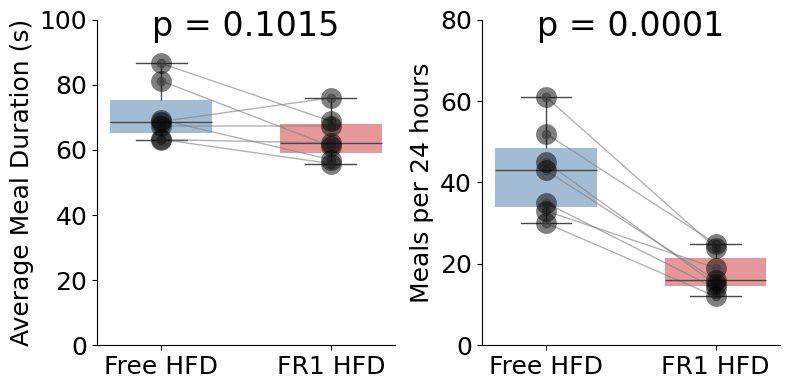

In [10]:
# @title Figure 1H

# Calculate a new stats_df that aggregates statistics for each unique filename
stats_df = Fig1Gdata.groupby(['filename', 'Sex', 'Device', 'Task']).agg(
    mean_feedDuration=('feedDuration', 'mean'),
    num_feeds=('feedDuration', 'count')
).reset_index()


# Define tasks to include
selected_tasks = ['Free HFD', 'FR1 HFD']  # Adjust this list to select tasks

# Filter data for selected tasks
filtered_stats_df = stats_df[stats_df['Task'].isin(selected_tasks)]

# Define common plot settings
plot_settings = {
    'boxprops': dict(alpha=0.5, edgecolor='none'),  # Set alpha for transparency
    'width': 0.6,
    'palette': sns.color_palette("Set1")[:2][::-1]  # Keep palette here
}

# @title Helper function for plotting
# Helper function to plot data
def plot_task_data(ax, y_column, ylabel, yticks):
    sns.boxplot(
        data=filtered_stats_df,
        x='Task',
        hue='Task',
        y=y_column,
        ax=ax,
        **plot_settings
    )
    sns.stripplot(
        data=filtered_stats_df,
        x='Task',
        y=y_column,
        ax=ax,
        color='black',
        alpha=0.5,
        size=15,
        jitter=False
    )
    for device, device_data in filtered_stats_df.groupby('Device'):
        task_indices = device_data['Task'].apply(lambda t: filtered_stats_df['Task'].unique().tolist().index(t))
        ax.plot(
            task_indices,
            device_data[y_column],
            color='gray',
            alpha=0.6,
            linestyle='-',
            linewidth=1,
            marker='o'
        )
    ax.set_xlabel('', fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_ylim(yticks[0], yticks[-1])  # Adjust y-limits to match y-ticks
    ax.set_yticks(yticks)  # Set y-ticks
    ax.tick_params(axis='both', which='major', labelsize=18)

    # Add p-value above the plot
    p_val = p_values[y_column]
    ax.text(
        0.5,  # Centered between the two tasks
        ax.get_ylim()[1] * 0.95,  # Slightly below the top of the y-axis
        f"p = {p_val:.4f}",
        ha='center',
        fontsize=24,
        color='black'
    )

# Perform paired t-tests
p_values = {}
for y_column in ['mean_feedDuration', 'num_feeds']:
    paired_data = filtered_stats_df.pivot(index='Device', columns='Task', values=y_column)
    ttest_result = pg.ttest(paired_data[selected_tasks[0]], paired_data[selected_tasks[1]], paired=True)
    p_values[y_column] = ttest_result['p-val'].values[0]


# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# Plot mean feed duration with yticks for axes[0]
plot_task_data(axes[0], 'mean_feedDuration', 'Average Meal Duration (s)', np.arange(0, 101, 20))

# Plot number of feeds with yticks for axes[1]
plot_task_data(axes[1], 'num_feeds', 'Meals per 24 hours', np.arange(0, 81, 20))

# Adjust layout and show the plot
sns.despine()
plt.tight_layout()

